In [1]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [8]:
img = cv2.imread('ICP/test_images/sharapova3.jpg')
img.shape

(555, 700, 3)

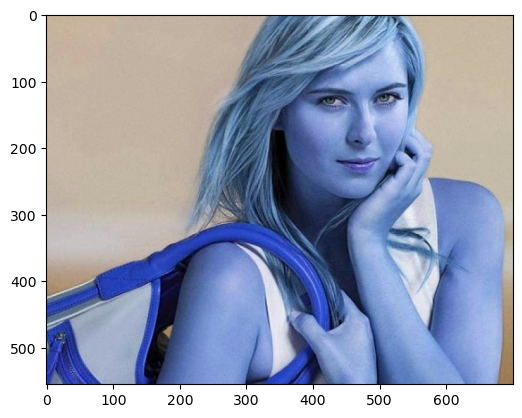

In [9]:
plt.imshow(img)

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray.shape

(555, 700)

In [11]:
gray

array([[175, 175, 175, ..., 176, 175, 174],
       [175, 175, 175, ..., 177, 175, 174],
       [175, 175, 175, ..., 177, 176, 174],
       ...,
       [ 84,  87,  88, ..., 113, 113, 113],
       [ 88,  89,  90, ..., 113, 113, 113],
       [ 93,  91,  91, ..., 112, 112, 112]], shape=(555, 700), dtype=uint8)

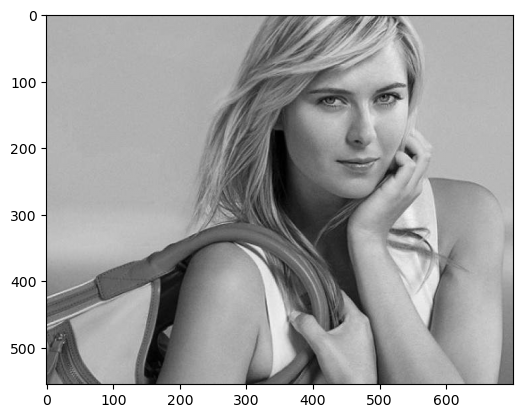

In [12]:
plt.imshow(gray, cmap='gray')

In [15]:
face_cascade = cv2.CascadeClassifier('ICP/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('ICP/haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[352,  38, 233, 233]], dtype=int32)

In [16]:
(x,y,w,h) = faces[0]
x,y,w,h

(np.int32(352), np.int32(38), np.int32(233), np.int32(233))

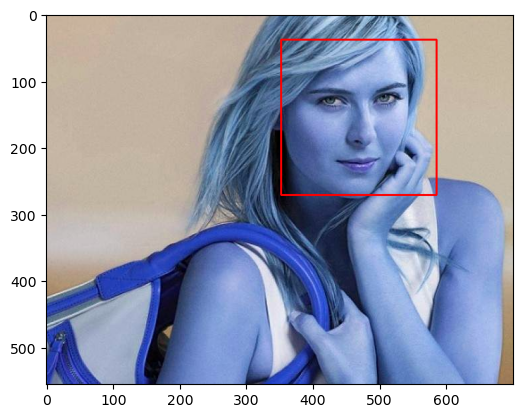

In [17]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

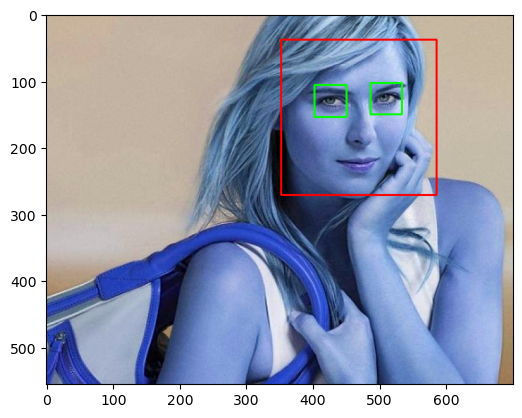

In [18]:
cv2.destroyAllWindows()
for (x,y,w,h) in faces:
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        

plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

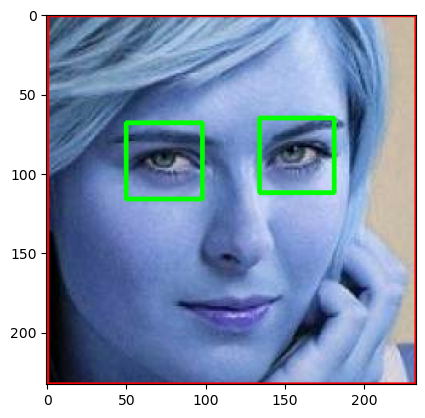

In [19]:
%matplotlib inline
plt.imshow(roi_color, cmap='gray')

In [20]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color

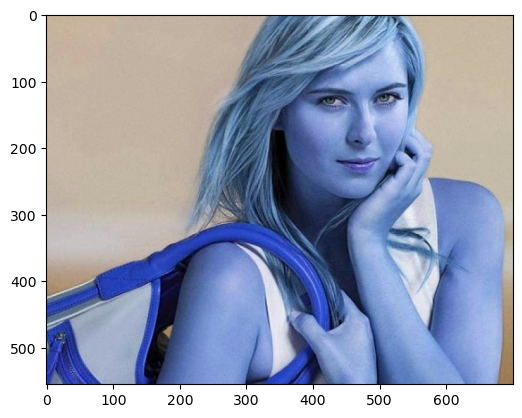

In [23]:
original_image = cv2.imread('ICP/test_images/sharapova3.jpg')
plt.imshow(original_image)

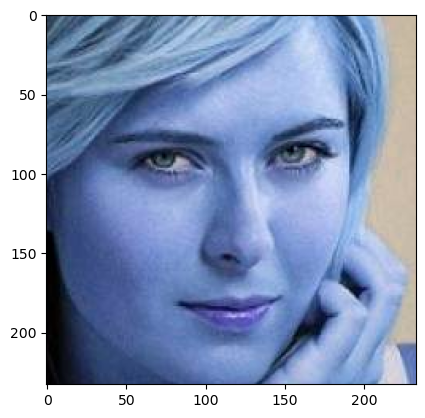

In [24]:
cropped_image = get_cropped_image_if_2_eyes('ICP/test_images/sharapova3.jpg')
plt.imshow(cropped_image)

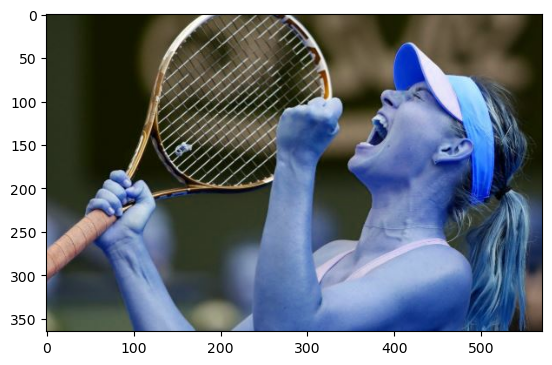

In [25]:
org_image_obstructed = cv2.imread('ICP/test_images/sharapova2.jpg')
plt.imshow(org_image_obstructed)

In [26]:
cropped_image_no_2_eyes = get_cropped_image_if_2_eyes('ICP/test_images/sharapova2.jpg')
cropped_image_no_2_eyes

In [39]:
path_to_data = "ICP/images_dataset"
path_to_cr_data = "ICP/cropped"

In [40]:
import shutil
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)

os.mkdir(path_to_cr_data)

In [41]:
img_dirs = []

for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)

In [42]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:

    count = 1
    celebrity_name = img_dir.split('/')[-1]

    celebrity_file_names_dict[celebrity_name] = []

    for entry in os.scandir(img_dir):

        if entry.path.lower().endswith((".png",".jpg",".jpeg")):

            roi_color = get_cropped_image_if_2_eyes(entry.path)

            if roi_color is not None:

                cropped_folder = path_to_cr_data + "/" + celebrity_name

                if not os.path.exists(cropped_folder):
                    os.makedirs(cropped_folder)
                    cropped_image_dirs.append(cropped_folder)

                cropped_file_name = celebrity_name + str(count) + ".png"

                cropped_file_path = cropped_folder + "/" + cropped_file_name

                cv2.imwrite(cropped_file_path, roi_color)

                celebrity_file_names_dict[celebrity_name].append(cropped_file_path)

                count += 1

In [43]:
## now we perform a wavelet tranformation for feature engineering

In [44]:
import pywt
import cv2
import numpy as np

def w2d(img, mode='haar', level=1):

    imArray = img
    
    # Convert to grayscale
    imArray = cv2.cvtColor(imArray, cv2.COLOR_RGB2GRAY)
    
    # Convert to float
    imArray = np.float32(imArray)
    imArray /= 255

    # Wavelet decomposition
    coeffs = pywt.wavedec2(imArray, mode, level=level)

    # Remove approximation
    coeffs_H = list(coeffs)
    coeffs_H[0] *= 0

    # Reconstruction
    imArray_H = pywt.waverec2(coeffs_H, mode)

    imArray_H *= 255
    imArray_H = np.uint8(imArray_H)

    return imArray_H

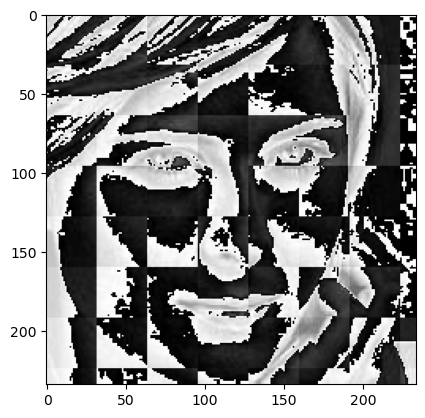

In [45]:
im_har=w2d(cropped_image,'db1',5)
plt.imshow(im_har,cmap='gray')

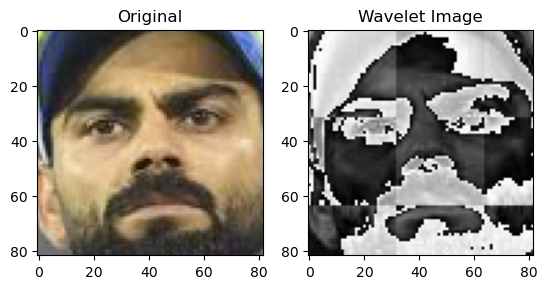

In [47]:
img = cv2.imread("ICP/cropped/virat_kohli/virat_kohli1.png")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

wavelet_img = w2d(img, 'haar', 5)

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")4

plt.subplot(1,2,2)
plt.imshow(wavelet_img, cmap='gray')
plt.title("Wavelet Image")

plt.show()

In [51]:
class_dict={}
count=0
for celebrity_name in celebrity_file_names_dict.keys():
    if celebrity_name == '.ipynb_checkpoints':
        continue
    class_dict[celebrity_name]=count
    count=count+1
class_dict    
    

{'maria_sharapova': 0,
 'virat_kohli': 1,
 'lionel_messi': 2,
 'serena_williams': 3,
 'roger_federer': 4}

In [53]:
X=[]
y=[]

for celebrity_name,training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img=cv2.imread(training_image)
        if img is None:
            continue
        scalled_raw_img=cv2.resize(img,(32,32))
        img_har=w2d(img,'db1',5)
        scalled_img_har=cv2.resize(img_har,(32,32))
        combined_img=np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])        



[ WARN:0@29905.949] global loadsave.cpp:278 findDecoder imread_('ICP/cropped/maria_sharapova/maria_sharapova1.png'): can't open/read file: check file path/integrity
[ WARN:0@29905.949] global loadsave.cpp:278 findDecoder imread_('ICP/cropped/maria_sharapova/maria_sharapova2.png'): can't open/read file: check file path/integrity
[ WARN:0@29906.019] global loadsave.cpp:278 findDecoder imread_('ICP/cropped/maria_sharapova/maria_sharapova7.png'): can't open/read file: check file path/integrity
[ WARN:0@29906.022] global loadsave.cpp:278 findDecoder imread_('ICP/cropped/maria_sharapova/maria_sharapova10.png'): can't open/read file: check file path/integrity
[ WARN:0@29906.055] global loadsave.cpp:278 findDecoder imread_('ICP/cropped/maria_sharapova/maria_sharapova20.png'): can't open/read file: check file path/integrity
[ WARN:0@29906.071] global loadsave.cpp:278 findDecoder imread_('ICP/cropped/maria_sharapova/maria_sharapova26.png'): can't open/read file: check file path/integrity
[ WARN:

In [59]:
32*32*3 + 32*32

4096

In [56]:
len(X[0])

4096

In [60]:
X[0]

array([[104],
       [139],
       [176],
       ...,
       [232],
       [ 38],
       [241]], shape=(4096, 1), dtype=uint8)

In [61]:
X=np.array(X).reshape(len(X),4096).astype(float)
X.shape

(143, 4096)

In [62]:
##training using svm

In [64]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [65]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)

In [70]:
pipe=Pipeline([('scaler',StandardScaler()),('svc',SVC(kernel='rbf',C=10))])
pipe.fit(X_train,y_train)
pipe.score(X_test,y_test)

0.7777777777777778

In [71]:
print(classification_report(y_test,pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.89      1.00      0.94         8
           2       0.50      0.80      0.62         5
           3       0.75      0.50      0.60         6
           4       1.00      0.57      0.73         7

    accuracy                           0.78        36
   macro avg       0.79      0.75      0.75        36
weighted avg       0.81      0.78      0.77        36



In [72]:
## now we use gridsearch cv

In [73]:
from sklearn.model_selection import GridSearchCV

In [101]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import pandas as pd
import joblib

# 1. Define your parameters
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto', probability=True),
        'params': {
            'C': [1, 10, 100, 1000],
            'kernel': ['rbf', 'linear']
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [1, 5, 10]
        }
    },
    'logistic_regression': {
        'model': LogisticRegression(solver='liblinear', multi_class='auto'),
        'params': {
            'C': [1, 5, 10]
        }
    }
}

# 2. Run the GridSearch
scores = []
best_estimators = {}

for algo, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    
    # Store the results for the dataframe
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    
    # STORE THE ACTUAL TRAINED MODEL HERE
    best_estimators[algo] = clf.best_estimator_

# 3. Display results
df = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
print(df)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/skle

                 model  best_score                   best_params
0                  svm    0.803030  {'C': 1, 'kernel': 'linear'}
1        random_forest    0.683983          {'n_estimators': 10}
2  logistic_regression    0.793506                      {'C': 1}


In [77]:
df=pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.803030,"{'C': 1, 'kernel': 'linear'}"
1,random_forest,0.625108,{'n_estimators': 10}
2,logistic_regression,0.793506,{'C': 1}


In [84]:
## hence use svm

In [102]:
best_estimators['svm'].score(X_test,y_test)

0.8333333333333334

In [103]:
best_estimators['logistic_regression'].score(X_test,y_test)

0.7777777777777778

In [104]:
best_clf=best_estimators['svm']

In [105]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,best_clf.predict(X_test))
cm

array([[9, 0, 1, 0, 0],
       [0, 8, 0, 0, 0],
       [1, 0, 4, 0, 0],
       [0, 0, 2, 4, 0],
       [0, 0, 1, 1, 5]])

Text(95.72222222222221, 0.5, 'Truth')

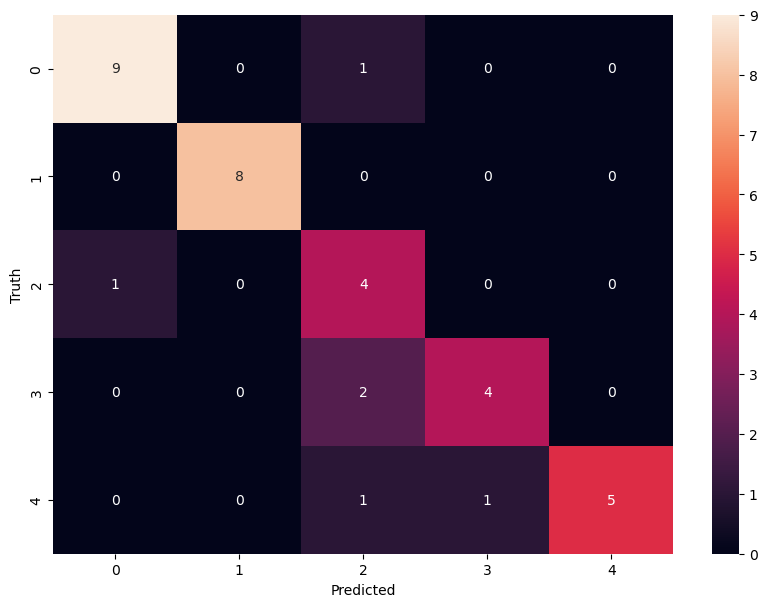

In [106]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [97]:
## save model

In [111]:
!pip install joblib
import joblib
#import as pickle in a file
joblib.dump(best_clf,'saved_model.pkl')

NameError: name 'scaler' is not defined

In [110]:
import json
with open('class_dictionary.json','w') as f:
    f.write(json.dumps(class_dict))